# Распознавание объектов на изображениях из набора данных CIFAR-10

Чтобы запускать и редактировать код, сохраните копию этого ноутбука себе (Файл -> Создать копию на Диске). Свою копию вы сможете изменять и запускать.

**Набор данных CIFAR-10** представляет собой набор изображений, которые обычно используются для обучения алгоритмов машинного обучения и компьютерного зрения. Набор данных CIFAR-10 содержит 60 000 цветных изображений размером 32x32 в 10 различных классах. В наборе содержится по 6000 изображений каждого класса.

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices()) 

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Названия классов из набора данных CIFAR-10
classes=['самолет', 'автомобиль', 'птица', 'кот', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

## Подготовка данных

**Загружаем данные**

In [5]:
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

In [6]:
X_train.shape

(50000, 32, 32, 3)

In [7]:
Y_train.shape

(50000, 1)

In [8]:
X_test.shape

(10000, 32, 32, 3)

**Просмотр примеров данных**

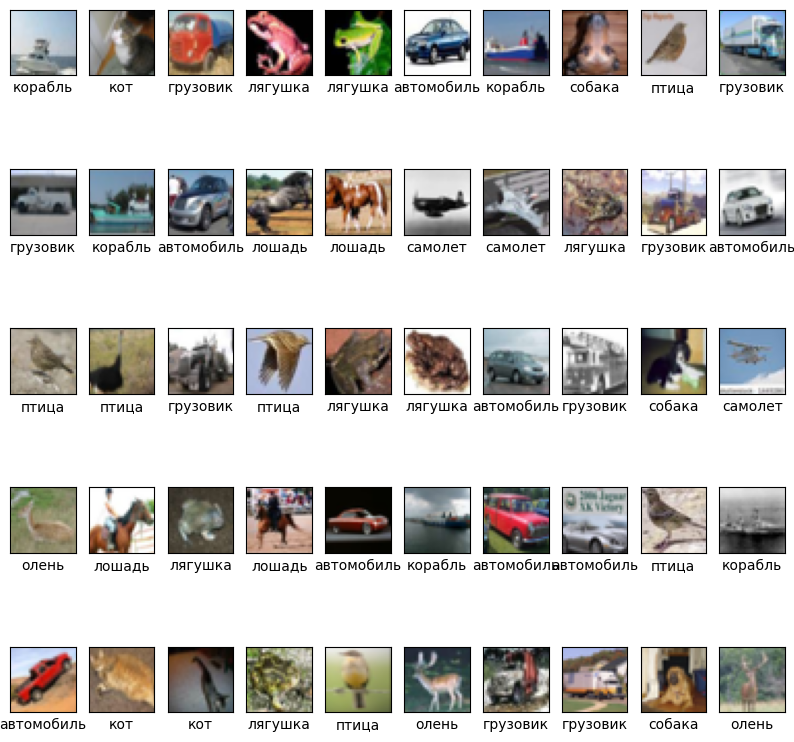

In [9]:
plt.figure(figsize=(10,10))
for i in range(100,150):
    plt.subplot(5,10,i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(classes[Y_train[i][0]])

**Нормализуем данные**

In [10]:
x_train = X_train / 255
x_test = X_test / 255

**Преобразуем правильные ответы в формат one hot encoding**

In [11]:
y_train = utils.to_categorical(Y_train, 10)
y_test = utils.to_categorical(Y_test, 10)

## Создаем нейронную сеть

In [12]:
# Создаем последовательную модель
model = Sequential()
# Первый сверточный слой
model.add(Conv2D(filters=32,  kernel_size=(3, 3), padding='same',
                        input_shape=(32, 32, 3), activation='relu'))
# Второй сверточный слой
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# Первый слой подвыборки
model.add(MaxPooling2D(pool_size=(2, 2)))

# Третий сверточный слой
model.add(Conv2D(64, (3, 3), activation='relu'))
# Четвертый сверточный слой
model.add(Conv2D(64, (3, 3), activation='relu'))
# Второй слой подвыборки
model.add(MaxPooling2D(pool_size=(2, 2)))

# Слой преобразования данных из 2D представления в плоское
model.add(Flatten())
# Полносвязный слой для классификации
model.add(Dense(512, activation='relu'))
model.add(Dense(128, activation='relu'))
# Слой регуляризации Dropout
model.add(Dropout(0.5))
# Выходной полносвязный слой
model.add(Dense(10, activation='softmax'))

**Печатаем информацию о сети**

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 12, 12, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                    

In [ ]:
!pip install visualkeras

import visualkeras

visualkeras.layered_view(model)

**Компилируем модель**

In [14]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

## Обучаем нейронную сеть

In [15]:
history = model.fit(x_train, y_train,
              batch_size=128,
              epochs=15,
              validation_split=0.1,
              verbose=2)

Epoch 1/15
352/352 - 67s - loss: 19.9130 - accuracy: 2.8092e-07 - val_loss: 2.3082 - val_accuracy: 0.0000e+00 - 67s/epoch - 190ms/step
Epoch 2/15
352/352 - 66s - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - 66s/epoch - 189ms/step
Epoch 3/15
352/352 - 64s - loss: 0.0000e+00 - accuracy: 7.9890e-09 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - 64s/epoch - 181ms/step
Epoch 4/15
352/352 - 64s - loss: 36.8569 - accuracy: 1.4080e-08 - val_loss: 0.0319 - val_accuracy: 0.0000e+00 - 64s/epoch - 181ms/step
Epoch 5/15
352/352 - 64s - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: nan - val_accuracy: 0.0000e+00 - 64s/epoch - 181ms/step
Epoch 6/15
352/352 - 64s - loss: 9.0900 - accuracy: 0.3194 - val_loss: 2.3058 - val_accuracy: 0.0000e+00 - 64s/epoch - 183ms/step
Epoch 7/15
352/352 - 67s - loss: 0.0000e+00 - accuracy: 8.9406e-09 - val_loss: 2.3067 - val_accuracy: -9.0125e-01 - 67s/epoch - 189ms/step
Epoch 8/15
352/352 - 68s - loss: 0.0000e+0

## Оцениваем качетсво обучения сети

In [16]:
# Оцениваем качество обучения модели на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=2)

313/313 - 2s - loss: 12.3353 - accuracy: -2.6327e-09 - 2s/epoch - 7ms/step


In [17]:
print("Доля верных ответов на тестовых данных, в процентах:", round(scores[1] * 100, 4))

Доля верных ответов на тестовых данных, в процентах: -0.0


In [ ]:
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

## Сохраняем обученную нейронную сеть

In [ ]:
model.save("cifar10_model.h5")

In [ ]:
!ls

Сохраняем модель на локальный компьютер

In [ ]:
files.download("cifar10_model.h5")

## Применяем сеть для распознавания объектов на изображениях

**Просмотр изображения из набора данных для тестирования**

In [ ]:
import random
index = random.randrange(0,9999)
plt.imshow(X_test[index])
plt.show()

**Преобразование тестового изображения**

In [ ]:
x = x_test[index]
x = np.expand_dims(x, axis=0)

**Запуск распознавания**

In [ ]:
prediction = model.predict(x)

**Печатаем результаты распознавания**

In [ ]:
print(prediction)

**Преобразуем результаты из формата one hot encoding**

In [ ]:
prediction = np.argmax(prediction)
print(classes[prediction])

**Печатаем правильный ответ**

In [ ]:
print(classes[Y_test[index][0]])

## Распознаем дополнительное изображение

In [ ]:
files.upload()

Проверяем загрузку файлов

In [ ]:
!ls

**Смотрим загруженную картинку**

In [ ]:
img_path = ''
img = image.load_img(img_path, target_size=(32, 32))
plt.imshow(img)
plt.show()

**Преобразуем картинку в массив для распознавания**

In [ ]:
x = image.img_to_array(img)
x /= 255
x = np.expand_dims(x, axis=0)

**Запускаем распознавание**

In [ ]:
prediction = model.predict(x)

In [ ]:
prediction

In [ ]:
prediction = np.argmax(prediction)
prediction

In [ ]:
print(classes[prediction])